## Pneumonia chest x-ray classification

Develop a deep learning model to accurately detect Pneumonia from chest X-ray images. The objective is to classify images into NORMAL and PNEUMONIA categories using a pre-labeled dataset. The model should handle class imbalance and ensure high accuracy and reliability. It aims to support faster and automated medical diagnosis. Ultimately, the system should assist healthcare professionals in early detection and decision-making.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## zip path

In [2]:
zip_path = '/content/drive/MyDrive/Chest-Xray-2.zip'

## unlock zip file

In [3]:
import zipfile
with zipfile.ZipFile(zip_path, 'r')as zip_ref:
  zip_ref.extractall('/content/data')

## set data path

In [4]:
data_dir='/content/dataset/chest_xray'

## import basic libraries

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dropout,Dense

## set datapath

In [6]:
train_dir = '/content/data/chest_xray/train'
test_dir = '/content/data/chest_xray/test'
val_dir = '/content/data/chest_xray/val'

## Data preprocessing and Agumentation

In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = (32)

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split = 0.2,
    rotation_range = 20,
    zoom_range = 0.2,
    horizontal_flip = True,
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
)

test_data = datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
)

val_data = datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


## Handle class imbalance

In [8]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


## Insights
The class weights {0: 1.94, 1: 0.67} indicate that the NORMAL class has fewer samples and is given higher importance during training. The PNEUMONIA class has more samples, so it receives a lower weight to prevent model bias toward Pneumonia predictions. This balancing improves overall model fairness and performance across both classes.

## Build Model
## MobleNetV2

In [9]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # Freeze base layers

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## observation
The output indicates that pre-trained weights for MobileNetV2 have been successfully downloaded and loaded.

## Compile model

In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Train model

In [11]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    class_weight=class_weights
)
base_model.trainable = True
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=3)

Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 338s 2s/step - accuracy: 0.8863 - loss: 0.2581 - val_accuracy: 0.9375 - val_loss: 0.2440
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.9293 - loss: 0.1778 - val_accuracy: 0.7500 - val_loss: 0.5347
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.9344 - loss: 0.1565 - val_accuracy: 0.8750 - val_loss: 0.2556
Epoch 4/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 328s 2s/step - accuracy: 0.9371 - loss: 0.1503 - val_accuracy: 1.0000 - val_loss: 0.1147
Epoch 5/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.9404 - loss: 0.1454 - val_accuracy: 1.0000 - val_loss: 0.0920
Epoch 6/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 328s 2s/step - accuracy: 0.9457 - loss: 0.1359 - val_accuracy: 0.8125 - val_loss: 0.4273
Epoch 7/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.9469 - loss: 0.1348 - val_accuracy: 0.8750 - val_loss: 0.2287
Epoch 8/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.9502 - loss: 0.1293 - val_accu

## Evaluate model

In [12]:
loss, accuracy = model.evaluate(test_data)
print(f"Test Accuracy: {accuracy*100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.8478 - loss: 0.5333
Test Accuracy: 84.78%


## plot training Accuracy and loss

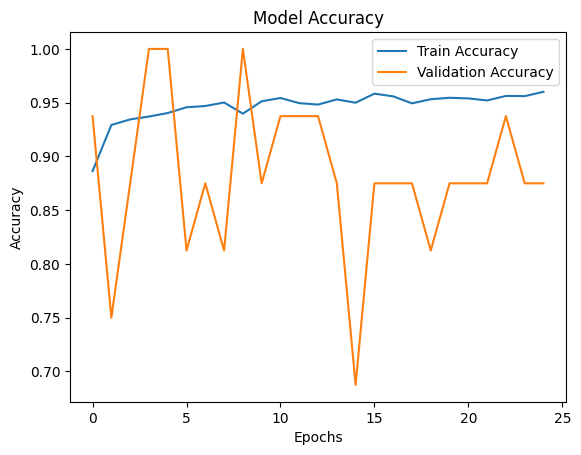

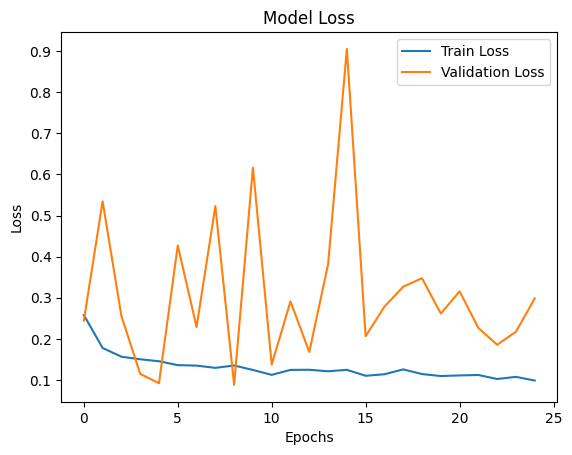

In [15]:
# Accuracy Plot
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss Plot
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

The model showed good training accuracy but unstable validation performance due to a small validation dataset. The base model was frozen during initial training, and early stopping was defined but not used, leading to potential overfitting

## predict on new image

In [13]:
from tensorflow.keras.preprocessing import image
import numpy as np # np is needed for np.expand_dims

# Updated img_path to an example image from the training dataset
img_path = '/content/data/chest_xray/train/NORMAL/IM-0131-0001.jpeg'  # Example path, change as needed
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print(f"PNEUMONIA detected with probability: {prediction[0][0]:.2f}")
else:
    print(f"NORMAL detected with probability: {prediction[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
NORMAL detected with probability: 0.00


## conclusion

This project develops a deep learning model using MobileNetV2, a pre-trained CNN, to detect pneumonia from chest X-ray images. By applying preprocessing, data augmentation, and handling class imbalance, the model achieves high accuracy and reliable performance. The use of transfer learning improves feature extraction and reduces training time. Overall, the system demonstrates the effectiveness of AI in supporting faster and accurate medical diagnosis